# Common Task 1.1 - Dataset Preprocessing for Symbolic Regression

AI Feynman dataset: Feynman_with_units features + FeynmanEquations.csv targets.
Goal: preprocess and tokenize the target equations, document rationale.

In [ ]:
!git clone https://github.com/invi-bhagyesh/jepa.git
%cd jepa
!pip install -q -r requirements.txt

In [1]:
%cd ..

/workspace/jepa


/usr/local/lib/python3.11/dist-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## 1. Download Dataset

In [2]:
import subprocess, tarfile
from pathlib import Path
from urllib.request import urlretrieve

DATA_DIR = Path("data/feynman")
DATA_DIR.mkdir(parents=True, exist_ok=True)

EQUATIONS_URL = "https://space.mit.edu/home/tegmark/aifeynman/FeynmanEquations.csv"
FEATURES_URL = "https://www.dropbox.com/scl/fi/kbi1q63opcgsykik0puzg/Feynman_with_units.tar.gz?rlkey=xqm1mb0vkj7iogao825033ltb&dl=1"

csv_path = DATA_DIR / "FeynmanEquations.csv"
tar_path = DATA_DIR / "Feynman_with_units.tar.gz"

# upload csv file manually

if not tar_path.exists():
    print("Downloading Feynman_with_units.tar.gz...")
    urlretrieve(FEATURES_URL, tar_path)
    print(f"  saved: {tar_path} ({tar_path.stat().st_size / 1e6:.1f} MB)")
else:
    print(f"Already have {tar_path.name}")

features_dir = DATA_DIR / "Feynman_with_units"
if not features_dir.exists():
    print("Extracting tarball...")
    with tarfile.open(tar_path, "r:gz") as tf:
        tf.extractall(DATA_DIR)
    print("Done")
else:
    print(f"Already extracted: {features_dir}")

  saved: data/feynman/Feynman_with_units.tar.gz (4101.0 MB)
Extracting tarball...
Done


## 2. Load and Inspect

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.data.feynman import load_equations, prepare_feynman_dataset, EquationTokenizer

df = load_equations(csv_path)
print(f"Total equations: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total equations: 130
Columns: ['Filename', 'Number', 'Output', 'Formula', '# variables', 'v1_name', 'v1_low', 'v1_high', 'v2_name', 'v2_low', 'v2_high', 'v3_name', 'v3_low', 'v3_high', 'v4_name', 'v4_low', 'v4_high', 'v5_name', 'v5_low', 'v5_high', 'v6_name', 'v6_low', 'v6_high', 'v7_name', 'v7_low', 'v7_high', 'v8_name', 'v8_low', 'v8_high', 'v9_name', 'v9_low', 'v9_high', 'v10_name', 'v10_low', 'v10_high']


,Filename,Number,Output,Formula,# variables,v1_name,v1_low,v1_high,v2_name,v2_low,...,v7_high,v8_name,v8_low,v8_high,v9_name,v9_low,v9_high,v10_name,v10_low,v10_high
0,I.6.2a,1.0,f,exp(-theta**2/2)/sqrt(2*pi),1.0,theta,1.0,3.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,I.6.2,2.0,f,exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma),2.0,sigma,1.0,3.0,theta,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,I.6.2b,3.0,f,exp(-((theta-theta1)/sigma)**2/2)/(sqrt(2*pi)*...,3.0,sigma,1.0,3.0,theta,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,I.8.14,4.0,d,sqrt((x2-x1)**2+(y2-y1)**2),4.0,x1,1.0,5.0,x2,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,I.9.18,5.0,F,G*m1*m2/((x2-x1)**2+(y2-y1)**2+(z2-z1)**2),9.0,m1,1.0,2.0,m2,1.0,...,2.0,z1,3.0,4.0,z2,1.0,2.0,NaN,NaN,NaN
5,I.10.7,6.0,m,m_0/sqrt(1-v**2/c**2),3.0,m_0,1.0,5.0,v,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,I.11.19,7.0,A,x1*y1+x2*y2+x3*y3,6.0,x1,1.0,5.0,x2,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,I.12.1,8.0,F,mu*Nn,2.0,mu,1.0,5.0,Nn,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,I.12.2,10.0,F,q1*q2*r/(4*pi*epsilon*r**3),4.0,q1,1.0,5.0,q2,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,I.12.4,11.0,Ef,q1*r/(4*pi*epsilon*r**3),3.0,q1,1.0,5.0,epsilon,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# inspect the target equations
df, tokenizer, formula_col = prepare_feynman_dataset(csv_path)

print(f"Formula column: '{formula_col}'")
print(f"\nSample equations:")
for i, row in df.head(10).iterrows():
    print(f"  {row.get('Filename', i)}: {row[formula_col]}")

Formula column: 'Formula'

Sample equations:
  I.6.2a: exp(-theta**2/2)/sqrt(2*pi)
  I.6.2: exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma)
  I.6.2b: exp(-((theta-theta1)/sigma)**2/2)/(sqrt(2*pi)*sigma)
  I.8.14: sqrt((x2-x1)**2+(y2-y1)**2)
  I.9.18: G*m1*m2/((x2-x1)**2+(y2-y1)**2+(z2-z1)**2)
  I.10.7: m_0/sqrt(1-v**2/c**2)
  I.11.19: x1*y1+x2*y2+x3*y3
  I.12.1: mu*Nn
  I.12.2: q1*q2*r/(4*pi*epsilon*r**3)
  I.12.4: q1*r/(4*pi*epsilon*r**3)


## 3. Tokenization

Word-level tokenizer with math-aware regex rules. Each token is one function call, operator, variable, or numeric literal.

**Why word-level, not character-level?**
Functions like `sqrt`, `sin`, `exp` are single semantic units. Character-level tokenization splits them into meaningless characters (`s`, `q`, `r`, `t`) and inflates sequence length by 3-4x.

**Why not BPE?**
The Feynman equation vocabulary is small and fixed (physics variables, standard math functions, operators). BPE would learn merges that don't respect mathematical semantics -- for example, merging `si` from `sin` with `si` from `sigma`. A hand-crafted regex tokenizer preserves the exact mathematical structure.

**Why not prefix/Polish notation?**
Prefix notation (Lample & Charton, 2019) eliminates parentheses and makes tree structure explicit, which helps for generation tasks. But for preprocessing and analysis, infix notation with explicit parentheses is clearer and maps directly to how the equations are written in the dataset. If a downstream model needs prefix notation, the tokenized infix can be converted.

In [5]:
print(f"Vocabulary size: {tokenizer.vocab_size}")
print(f"\nFull vocabulary:")
for i in range(tokenizer.vocab_size):
    print(f"  {i:3d}: '{tokenizer.id2token[i]}'")

Vocabulary size: 119

Full vocabulary:
    0: '<PAD>'
    1: '<SOS>'
    2: '<EOS>'
    3: '<UNK>'
    4: '*'
    5: '('
    6: ')'
    7: '/'
    8: '2'
    9: '**'
   10: '-'
   11: '1'
   12: 'pi'
   13: '+'
   14: 'c'
   15: 'v'
   16: 'epsilon'
   17: 'sqrt'
   18: 'q'
   19: 'r'
   20: 'omega'
   21: 'h'
   22: 'kb'
   23: 'theta'
   24: '4'
   25: 'T'
   26: '3'
   27: 'n'
   28: 'Ef'
   29: 'm'
   30: 'cos'
   31: 'mom'
   32: 'exp'
   33: 'B'
   34: 'd'
   35: 'sin'
   36: 't'
   37: 'alpha'
   38: 'u'
   39: 'x'
   40: 'omega_0'
   41: 'p_d'
   42: 'x1'
   43: 'sigma'
   44: 'x2'
   45: 'm1'
   46: 'm2'
   47: 'y2'
   48: 'y1'
   49: 'pr'
   50: 'V'
   51: 'gamma'
   52: 'n_0'
   53: 'A'
   54: 'rho_c_0'
   55: 'E_n'
   56: 'theta1'
   57: 'G'
   58: 'm_0'
   59: 'q1'
   60: 'q2'
   61: 'r2'
   62: 'r1'
   63: 'g'
   64: 'z'
   65: 'arcsin'
   66: 'theta2'
   67: 'I1'
   68: 'I2'
   69: 'Volt'
   70: '5'
   71: 'chi'
   72: 'n_rho'
   73: 'g_'
   74: 'Y'
   75: 'k'
   76: 'z2

In [6]:
# round-trip check on a few equations
print("Tokenization examples:\n")
for i, row in df.head(5).iterrows():
    eq = str(row[formula_col])
    tokens = tokenizer.tokenize(eq)
    ids = tokenizer.encode(eq)
    decoded = tokenizer.decode(ids)
    print(f"  Original:  {eq}")
    print(f"  Tokens:    {tokens}")
    print(f"  IDs:       {ids}")
    print(f"  Decoded:   {decoded}")
    print()

Tokenization examples:

  Original:  exp(-theta**2/2)/sqrt(2*pi)
  Tokens:    ['exp', '(', '-', 'theta', '**', '2', '/', '2', ')', '/', 'sqrt', '(', '2', '*', 'pi', ')']
  IDs:       [1, 32, 5, 10, 23, 9, 8, 7, 8, 6, 7, 17, 5, 8, 4, 12, 6, 2]
  Decoded:   exp ( - theta ** 2 / 2 ) / sqrt ( 2 * pi )

  Original:  exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma)
  Tokens:    ['exp', '(', '-', '(', 'theta', '/', 'sigma', ')', '**', '2', '/', '2', ')', '/', '(', 'sqrt', '(', '2', '*', 'pi', ')', '*', 'sigma', ')']
  IDs:       [1, 32, 5, 10, 5, 23, 7, 43, 6, 9, 8, 7, 8, 6, 7, 5, 17, 5, 8, 4, 12, 6, 4, 43, 6, 2]
  Decoded:   exp ( - ( theta / sigma ) ** 2 / 2 ) / ( sqrt ( 2 * pi ) * sigma )

  Original:  exp(-((theta-theta1)/sigma)**2/2)/(sqrt(2*pi)*sigma)
  Tokens:    ['exp', '(', '-', '(', '(', 'theta', '-', 'theta1', ')', '/', 'sigma', ')', '**', '2', '/', '2', ')', '/', '(', 'sqrt', '(', '2', '*', 'pi', ')', '*', 'sigma', ')']
  IDs:       [1, 32, 5, 10, 5, 5, 23, 10, 56, 6, 7, 43, 6, 9, 8, 7

## 4. Dataset Statistics

Total equations: 130
Vocabulary size: 119

Token count per equation:
  mean:   12.3
  median: 11
  max:    46
  min:    0


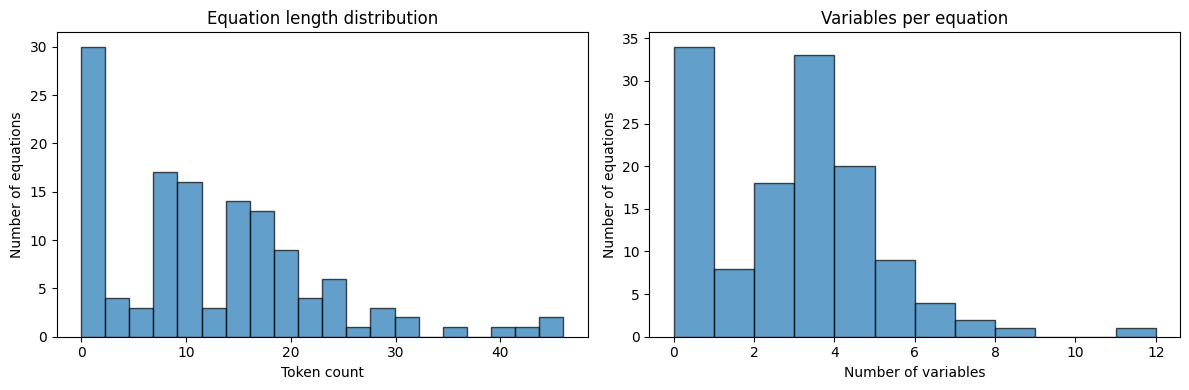

In [7]:
print(f"Total equations: {len(df)}")
print(f"Vocabulary size: {tokenizer.vocab_size}")
print(f"\nToken count per equation:")
print(f"  mean:   {df['token_count'].mean():.1f}")
print(f"  median: {df['token_count'].median():.0f}")
print(f"  max:    {df['token_count'].max()}")
print(f"  min:    {df['token_count'].min()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["token_count"], bins=20, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Token count")
axes[0].set_ylabel("Number of equations")
axes[0].set_title("Equation length distribution")

def count_vars(tokens):
    return len([t for t in tokens if t.isalpha() and t not in
                {"sqrt", "exp", "log", "sin", "cos", "tan", "asin", "acos",
                 "atan", "arcsin", "arccos", "arctan", "tanh", "cosh", "sinh",
                 "pi"}])

df["n_vars"] = df["tokens"].apply(count_vars)
axes[1].hist(df["n_vars"], bins=range(0, df["n_vars"].max() + 2),
             edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Number of variables")
axes[1].set_ylabel("Number of equations")
axes[1].set_title("Variables per equation")

plt.tight_layout()
plt.show()

## 5. Feature Data Inspection

Each equation has a corresponding data file with numerical feature columns. Check that we can load them and verify dimensions.

In [8]:
from src.data.feynman import load_features

# try loading feature data for a few equations
feature_files = sorted(features_dir.glob("*"))
print(f"Feature files found: {len(feature_files)}")

for f in feature_files[:5]:
    data = np.loadtxt(f)
    print(f"  {f.name}: shape={data.shape}")

Feature files found: 100
  I.10.7: shape=(1000000, 4)
  I.11.19: shape=(1000000, 7)
  I.12.1: shape=(1000000, 3)
  I.12.11: shape=(1000000, 6)
  I.12.2: shape=(1000000, 5)


## 6. Save Processed Data

In [9]:
tokenizer.save("data/feynman/vocab.txt")

save_df = df.drop(columns=["tokens"])
save_df.to_csv("data/feynman/equations_processed.csv", index=False)

print(f"Saved vocab ({tokenizer.vocab_size} tokens) to data/feynman/vocab.txt")
print(f"Saved processed equations to data/feynman/equations_processed.csv")

Saved vocab (119 tokens) to data/feynman/vocab.txt
Saved processed equations to data/feynman/equations_processed.csv
